In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import CountVectorizer

In [22]:
# Download NLTK Data 

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sanke\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\sanke\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [23]:
# Load dataset
cols = ['Complaint Type', 'Descriptor', 'Borough', 'Created Date']

df = pd.read_csv("../data/raw/311_Service_Requests_for_2009.csv", usecols=cols)

df.head()

,Created Date,Complaint Type,Descriptor,Borough
0,01/01/2009 12:00:00 AM,HEATING,HEAT,Unspecified
1,01/01/2009 12:00:00 AM,Smoking,Smoking Violation,QUEENS
2,01/01/2009 12:00:00 AM,Traffic Signal Condition,Controller,BROOKLYN
3,01/01/2009 12:00:00 AM,Traffic Signal Condition,Controller,BROOKLYN
4,01/01/2009 12:00:00 AM,Traffic Signal Condition,Controller,BROOKLYN


In [24]:
def clean_text(text):
    if pd.isna(text):
        return ""
    return text.lower()

df['cleaned_text'] = df['Descriptor'].apply(clean_text)

df.to_csv("../data/processed/cleaned_data.csv", index=False)

In [25]:

df.info()

df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1783133 entries, 0 to 1783132
Data columns (total 5 columns):
 #   Column          Dtype
---  ------          -----
 0   Created Date    str  
 1   Complaint Type  str  
 2   Descriptor      str  
 3   Borough         str  
 4   cleaned_text    str  
dtypes: str(5)
memory usage: 68.0 MB


Created Date         0
Complaint Type       0
Descriptor        5540
Borough              0
cleaned_text         0
dtype: int64

In [26]:
# Handle missing values
df['Complaint Type'] = df['Complaint Type'].fillna('')
df['Descriptor'] = df['Descriptor'].fillna('')
df['Borough'] = df['Borough'].fillna('Unknown')

In [27]:
# Combine complaint type and descriptor
df['text'] = df['Complaint Type'] + " " + df['Descriptor']

In [28]:
# Setup NLP Tools

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [29]:
# Text Cleaning

def clean_text(text):
    text = str(text).lower()  # Convert to lowercase
    
    text = re.sub(r"http\S+|www\S+", '', text)  # Remove URLs
    
    text = re.sub(r"[^a-z\s]", '', text)  # Remove special characters
    
    words = text.split()
    
    # Remove stopwords + apply lemmatization
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    
    return " ".join(words)

In [30]:
# Apply Cleaning

df['clean_text'] = df['text'].apply(clean_text)

df[['text', 'clean_text']].head()

,text,clean_text
0,HEATING HEAT,heating heat
1,Smoking Smoking Violation,smoking smoking violation
2,Traffic Signal Condition Controller,traffic signal condition controller
3,Traffic Signal Condition Controller,traffic signal condition controller
4,Traffic Signal Condition Controller,traffic signal condition controller


In [31]:
colors = sns.color_palette("husl", 10)

In [32]:
sns.set_style("whitegrid")
sns.set_palette("husl")

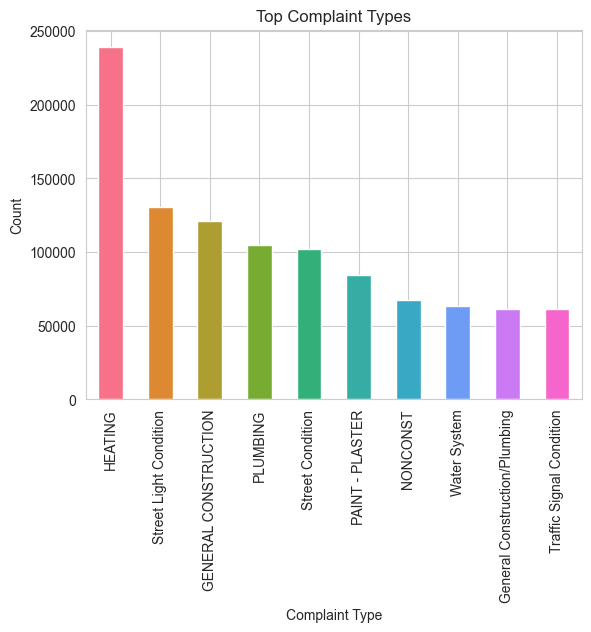

In [33]:
df['Complaint Type'].value_counts().head(10).plot(kind='bar', color=colors)
plt.title("Top Complaint Types")
plt.xlabel("Complaint Type")
plt.ylabel("Count")
plt.show()

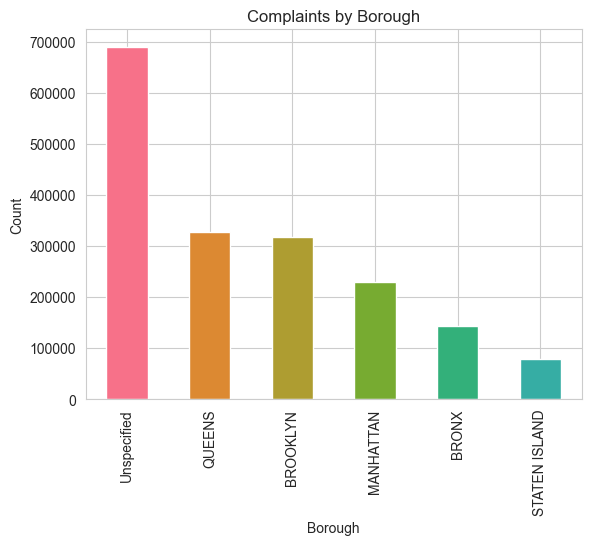

In [34]:
# Borough Analsis

df['Borough'].value_counts().plot(kind='bar', color=colors)
plt.title("Complaints by Borough")
plt.xlabel("Borough")
plt.ylabel("Count")
plt.show()

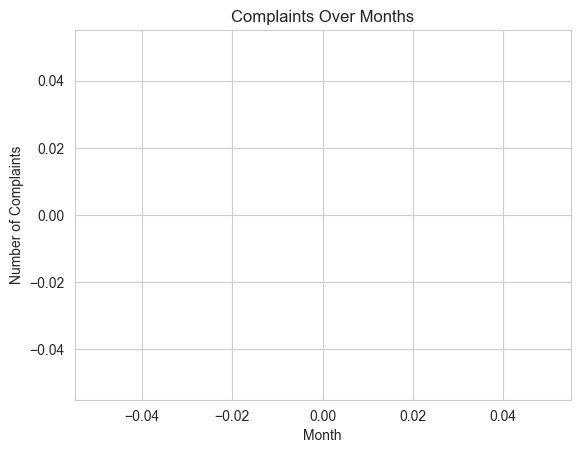

In [35]:
# Time Analysis

df['Created Date'] = pd.to_datetime(
    df['Created Date'], 
    format='%m/%d/%y %H:%M:%S', 
    errors='coerce')

df['Created Date'].dt.month.value_counts().sort_index().plot()
plt.title("Complaints Over Months")
plt.xlabel("Month")
plt.ylabel("Number of Complaints")
plt.show()

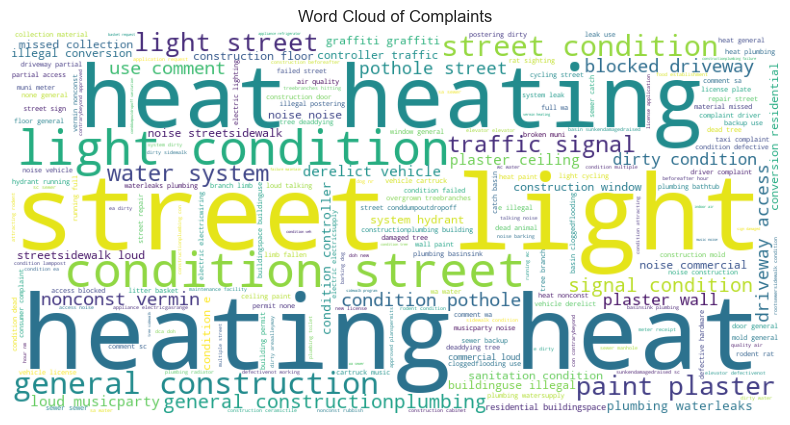

In [36]:
# Word Cloud 


text_data = " ".join(df['clean_text'])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_data)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis('off')
plt.title("Word Cloud of Complaints")
plt.show()

In [37]:
# N-grams(Unigrams) 

vectorizer = CountVectorizer(ngram_range=(1,1), max_features=10)
X = vectorizer.fit_transform(df['clean_text'])

words = vectorizer.get_feature_names_out()
counts = X.sum(axis=0).A1

unigram_df = pd.DataFrame({'word': words, 'count': counts})
unigram_df.sort_values(by='count', ascending=False)

,word,count
9,street,413872
0,condition,402409
5,light,246331
3,heat,239739
4,heating,239090
2,general,185286
6,noise,148484
1,construction,139771
8,plumbing,110882
7,paint,84324


In [38]:
#Bigrams

vectorizer = CountVectorizer(ngram_range=(2,2), max_features=10)
X = vectorizer.fit_transform(df['clean_text'])

bigrams = vectorizer.get_feature_names_out()
counts = X.sum(axis=0).A1

bigram_df = pd.DataFrame({'bigram': bigrams, 'count': counts})
bigram_df.sort_values(by='count', ascending=False)

,bigram,count
7,street light,244126
3,heating heat,236963
4,light condition,130242
0,condition street,128575
1,general construction,121048
6,street condition,103031
5,paint plaster,84324
9,water system,62991
8,traffic signal,61814
2,general constructionplumbing,61288


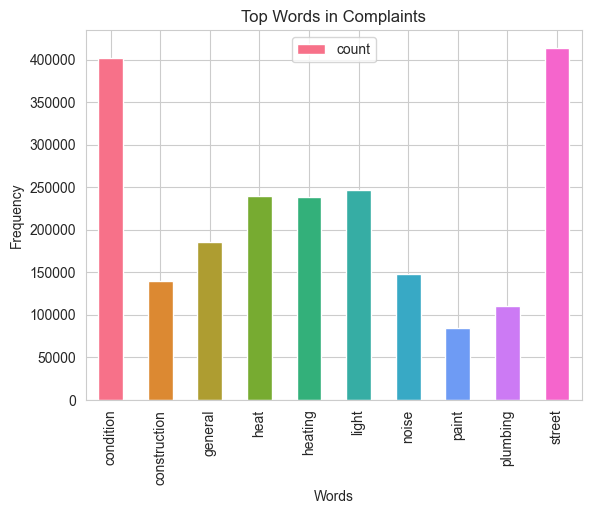

In [39]:
unigram_df.plot(x='word', y='count', kind='bar', color=colors)
plt.title("Top Words in Complaints")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()